In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

import os
from dotenv import load_dotenv


load_dotenv()

True

In [2]:
wiki_wrapper = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=wiki_wrapper)
wiki

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'd:\\LIFE\\_BOOTCAMP_MANDIRI\\B11_LANGGRAPH\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=500))

In [3]:
response = wiki.invoke("Apa itu attention is all you need")
print(response)

Page: August 2025 Indonesian protests
Summary: On 25 August until early September 2025, several protests took place in Indonesia as part of a larger civil unrest that began in early 2025 over economic frustrations and a proposed hike in housing subsidies for members of parliament. Protesters initially demanded the House of Representatives reverse its subsidy schemes and penalize its members who made insensitive statements, as well as pass the Confiscation of Assets Act for lawmakers convicted of


In [4]:
arxiv_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=arxiv_wrapper)
arxiv

ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500))

In [5]:
response = arxiv.invoke("Machine learning")

In [6]:
print(response)

Published: 2023-06-07
Title: Changing Data Sources in the Age of Machine Learning for Official Statistics
Authors: Cedric De Boom, Michael Reusens
Summary: Data science has become increasingly essential for the production of official statistics, as it enables the automated collection, processing, and analysis of large amounts of data. With such data science practices in place, it enables more timely, more insightful and more flexible reporting. However, the quality and integrity of data-science-


In [7]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_ENDPOINT"] = os.getenv("LANGSMITH_ENDPOINT")
os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING")
os.environ["LANGSMITH_PROJECT"] = "ReActAgent"




In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

# Tavily search Tool
tavily_tool = TavilySearchResults()

C:\Users\Farhan Kamil\AppData\Local\Temp\ipykernel_5736\1522468895.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults()


In [9]:
response = tavily_tool.invoke("Berikan Bootcamp terbaru tentang ai engineer gratis")
print(response)

[{'title': 'The 5 Best AI Engineering Bootcamps in 2026 - TripleTen', 'url': 'https://tripleten.com/blog/posts/best-ai-engineering-bootcamps', 'content': 'Evaluate your background: Never coded in your life? Not even sure what AI is? You’re probably best suited for TripleTen’s program or dipping your toes into AI workflows with BrainStation’s bootcamp. Alternatively, if you’ve already toyed with chatbots or done some basic AI modeling, or worked as an engineer for at least a year, you could qualify for the Caltech or Fullstack bootcamps. Anyone more advanced than that should consider Columbia’s or a similar intensive program. [...] Do your research: Learn as much as you can about a program before taking the leap. This could mean reading student reviews, browsing the organization’s website, or meeting with an instructor or contacting alumni to get your burning questions answered. (You can do this for free with a TripleTen advisor!) [...] |  |  |  |  |\n ---  --- |\n| Audience | Focus | P

In [10]:

def add(a: int, b:int) -> int:
    """
        Function untuk melakukan pertambahan pada suatu bilangan
        
        argumen:
            a : bilangan pertama
            b : bilangan kedua
    """
    
    return a + b
    
# Menyatukan Tools yang ada
tools = [arxiv, wiki, tavily_tool, add]

In [11]:
from langchain_groq import ChatGroq

model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)
llm_with_tools = model.bind_tools(tools)

In [12]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage

response = llm_with_tools.invoke([HumanMessage(content=f"Carikan aku bootcamp ai engineer yang gratis dan buku yang murah")])

In [13]:
response.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'free AI engineer bootcamp'},
  'id': 'fc_3505f0e9-94be-47b8-899b-e2de005194fb',
  'type': 'tool_call'}]

In [30]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_classic.schema import Document

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from langchain_classic.tools.retriever import create_retriever_tool



class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]
    retrieved_doc : list[Document] = []
    
def retrieve_docs():
    """
        Retrieve document about agent
    """
    
    loader = TextLoader("text.txt")
    docs = loader.load()
    
    embedding = OpenAIEmbeddings()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap = 80)
    chunks = text_splitter.split_documents(docs)
    
    vectorstore = FAISS.from_documents(documents=chunks, embedding=embedding)
    retriever = vectorstore.as_retriever()
    return retriever

retriever = retrieve_docs()

retriever_tool = create_retriever_tool(
    retriever,
    name="search_text_file",
    description="Search for information about the agent from the text.txt file."
)
tools = [arxiv, wiki, tavily_tool, add, retriever_tool]


In [31]:
llm_with_tools = model.bind_tools(tools)

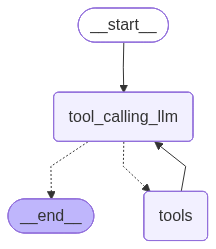

In [32]:
from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# node definisi
def tool_calling_llm(state:State) -> State:
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

memory = MemorySaver()
builder_graph = builder.compile(checkpointer=memory)
display(Image(builder_graph.get_graph().draw_mermaid_png()))


In [34]:
response = builder_graph.invoke({"messages" : HumanMessage(content=f"bisa berikan isi untuk text.txt? ")}, config = {"configurable" : {"thread_id" : 1}})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

bisa berikan isi untuk text.txt? 
================================== Ai Message ==================================
Tool Calls:
  search_text_file (fc_44bf162f-3ad2-4481-8ccb-11ec6c466426)
 Call ID: fc_44bf162f-3ad2-4481-8ccb-11ec6c466426
  Args:
    query:
================================= Tool Message =================================
Name: search_text_file

key parts.Retrieval-Augmented Generation (RAG) from basics to advanced", "url": "https://medium.com/@tejpal.abhyuday/retrieval-augmented-generation-rag-from-basics-to-advanced-a2b068fd576c", "content": "The last step of the RAG pipeline is to generate responses back to the user. In this step, the

involves integrating the insights gleaned from various sources, ensuring accuracy and relevance, and crafting a response that is not only informative but also aligns with the userâ€™s original query, maintaining a natural and conversational tone. [...] 1. V

In [ ]:
response = builder_graph.invoke({"messages" : HumanMessage(content=f"Apa itu machine learning?")})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Apa itu machine learning?
================================== Ai Message ==================================

**Machine Learning (Pembelajaran Mesin)** adalah sebuah bidang dalam kecerdasan buatan (Artificial Intelligence/AI) yang fokus pada pengembangan algoritma dan model statistik yang memungkinkan komputer **belajar dari data** tanpa harus diprogram secara eksplisit untuk setiap tugas. Dengan kata lain, alih‑alih menuliskan aturan‑aturan logika yang kaku, kita melatih sistem dengan contoh‑contoh (data) sehingga ia dapat menemukan pola, membuat prediksi, atau mengambil keputusan secara otomatis.

### Konsep Utama

| Konsep | Penjelasan |
|--------|------------|
| **Data** | Kumpulan contoh (fitur) yang menggambarkan masalah, misalnya gambar, teks, sinyal suara, atau data tabular. |
| **Model** | Struktur matematis (mis. jaringan saraf, pohon keputusan, regresi) yang memetakan input menjadi output. |
| **